# create split dict
use 90% as training and 10% as validation

In [ ]:
import scanpy as sc
import numpy as np

In [ ]:
adata = sc.read_h5ad("../data/preprocessed_replogle_2022_k562_gwps.h5ad", backed='r')
adata

In [ ]:
def make_split(adata, train_fraction=0.75, val_fraction=0.1, test_fraction=0.15, random_seed=42, save_path=None):
    # Get all unique conditions
    all_conditions = adata.obs['condition'].unique().tolist()
    non_ctrl = [c for c in all_conditions if c != 'ctrl']

    # Shuffle for reproducibility
    rng = np.random.default_rng(seed=random_seed)
    shuffled = rng.permutation(non_ctrl).tolist()

    # Split sizes (based on non-ctrl conditions)
    n = len(shuffled)
    n_train = int(np.round(n * train_fraction))
    n_val = int(np.round(n * val_fraction))
    n_test = n - n_train - n_val

    train_conds = shuffled[:n_train]
    val_conds = shuffled[n_train:n_train + n_val]
    test_conds = shuffled[n_train + n_val:]

    # 'ctrl' always goes to train
    train_conds = train_conds + ['ctrl']

    split_dict = {
        'train': train_conds,
        'val': val_conds,
        'test': test_conds,
    }

    print(f"Total conditions: {len(all_conditions)}  (ctrl + {len(non_ctrl)} perturbations)")
    print(f"Train: {len(train_conds)} | Val: {len(val_conds)} | Test: {len(test_conds)}")
    
    # Save if path provided
    if save_path:
        import pickle
        import os
        # Create directory if it doesn't exist
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        with open(save_path, 'wb') as f:
            pickle.dump(split_dict, f)
        print(f"Split saved to: {save_path}")
    
    return split_dict

In [ ]:
split_dict = make_split(
    adata, 
    train_fraction=0.90, 
    val_fraction=0.1, 
    test_fraction=0.0,
    random_seed=42, 
    save_path="../data/gfm/replogle_k562_gwps/split_no_test.pkl")

# Train

In [ ]:
%%bash
dataset="replogle_k562_gwps"
adata_path="../data/preprocessed_replogle_2022_k562_gwps.h5ad"

python ../scripts/gfm_run_all.py \
    --adata-path "${adata_path}" \
    --split-dict-path "../data/gfm/replogle_k562_gwps/split_no_test.pkl" \
    --output_dir "../data/gfm/replogle_k562_gwps/" \
    --vae-name "vae.pt" \
    --model-name "gfm_go_gwps_ppi.pt" \
    --graph-type "go+pert+ppi" \
    --pert-encoding "gat" \
    --graph-dir "../data/" \
    --skip-prediction \
    --skip-metrics \

# Predict all perturbations

In [ ]:
import scanpy as sc
import torch
import pandas as pd

from gfm import GFM

In [ ]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
adata = sc.read_h5ad("../data/preprocessed_replogle_2022_k562_gwps.h5ad", backed='r')
pert_adata_path="../data/preprocessed_replogle_2022_k562_gwps.h5ad"
gfm = GFM(
    adata,
    split_dict_path="../data/gfm/replogle_k562_gwps/split_no_test.pkl",
    output_dir="../data/gfm/replogle_k562_gwps/",
    model_name="gfm_go_gwps_ppi.pt",
    device=device,
)
gfm.initialize_fm(graph_type="go+pert+ppi", pert_encoding="gat", pert_adata_path=pert_adata_path)
gfm.load_model()
pred_df = pd.DataFrame({'condition': gfm.pert_names_graph})
adata_pred = gfm.predict(pred_df, n_cells=20)
adata_pred.write_h5ad("../data/gfm/replogle_k562_gwps/adata_pred_all_go+gwps+ppi.h5ad")

# t-SNE

In [ ]:
adata_pred = sc.read_h5ad("../data/gfm/replogle_k562_gwps/adata_pred_all_go+gwps+ppi.h5ad", backed='r')

In [ ]:
from gfm.helpers import SplitHandler
split_handler = SplitHandler(split_dict_path="../data/gfm/replogle_k562_gwps/split_no_test.pkl")

In [ ]:
import decoupler as dc
adata_pred_mean = dc.pp.pseudobulk(
    adata=adata_pred,
    sample_col="condition",
    groups_col="condition",
    mode="mean"
)

In [ ]:
sc.pp.pca(adata_pred_mean)
sc.pp.neighbors(adata_pred_mean)
sc.tl.leiden(adata_pred_mean, resolution=0.5)
sc.tl.umap(adata_pred_mean)

In [ ]:
sc.tl.tsne(adata_pred_mean)

In [ ]:
# Annotate clusters by DE genes
sc.tl.rank_genes_groups(adata_pred_mean, groupby='leiden', method='wilcoxon')

In [ ]:
from tqdm import tqdm
import gseapy as gp
cluster_function_dict = {}
for leiden_cluster in tqdm(adata_pred_mean.obs['leiden'].unique().tolist()):
    genes = adata_pred_mean.uns['rank_genes_groups']['names'][leiden_cluster][-100:].tolist()
    enr = gp.enrich(gene_list=genes,
                    gene_sets='GO_Biological_Process_2025')
    if enr.res2d.empty:
        cluster_function_dict[leiden_cluster] = 'NA'
    else:
        cluster_function_dict[leiden_cluster] = enr.res2d['Term'][0].split(' (')[0]

100%|██████████| 9/9 [00:21<00:00,  2.36s/it]


In [ ]:
adata_pred_mean.obs['cluster_function'] = adata_pred_mean.obs['leiden'].map(cluster_function_dict)

def trim_cond(cond):
    filtered = '+'.join(p for p in cond.split('+') if p != 'ctrl')
    return filtered if filtered else 'ctrl'
perts_in_train = set([item for cond in split_handler.split_dict['train'] for item in trim_cond(cond).split('+')])

# add a column "split" in adata_pred_mean.obs, where the value is "seen" if name is in perts_in_train, and "unseen" otherwise
adata_pred_mean.obs['split'] = adata_pred_mean.obs['condition'].apply(lambda x: 'seen' if x in perts_in_train else 'unseen')

In [ ]:
adata_pred_mean.write_h5ad("../data/gfm/replogle_k562_gwps/adata_pred_mean_all_go+gwps+ppi.h5ad")

In [ ]:
adata_pred_mean = sc.read_h5ad("../data/gfm/replogle_k562_gwps/adata_pred_mean_all_go+gwps+ppi.h5ad")

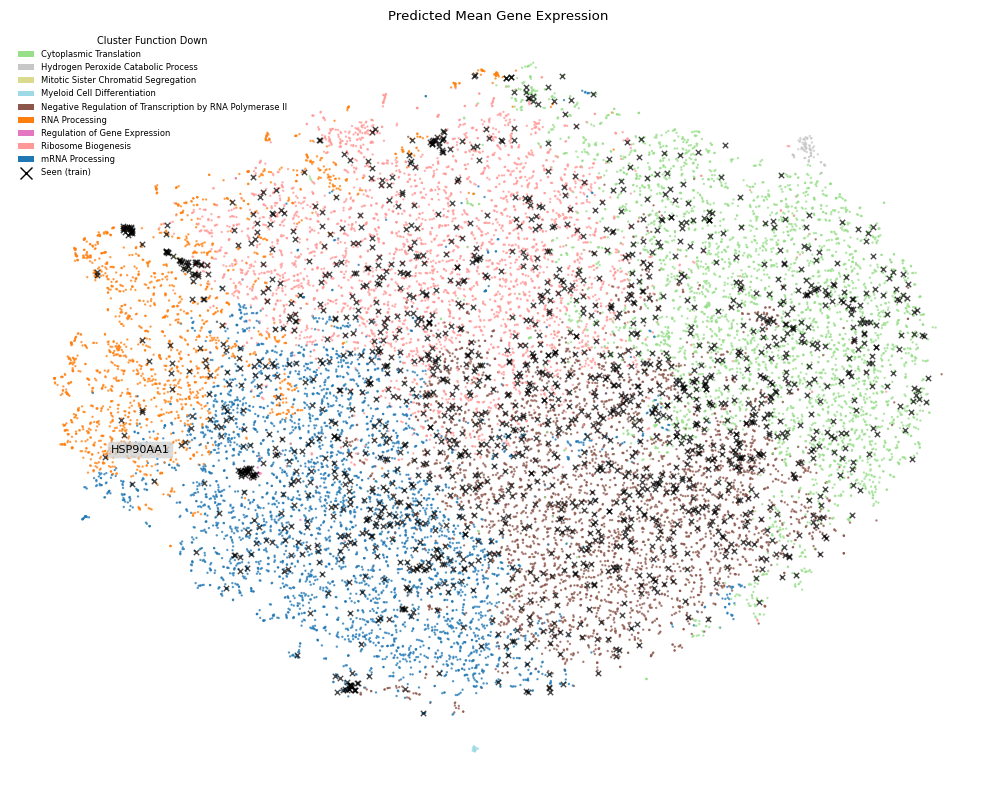

In [ ]:
from matplotlib.lines import Line2D


def plot_umap_pert_emb(adata_pert_emb, label_genes=None, figsize=(12, 10), save_path=None):
    """
    Plot t-SNE visualization of perturbation embeddings colored by Leiden clusters.
    Parameters:
    -----------
    adata_pert_emb : AnnData
        AnnData object containing perturbation embeddings with:
        - obsm['X_tsne']: t-SNE coordinates
        - obs['leiden']: Leiden cluster assignments
        - obs['split']: 'seen' or 'unseen' split
        - obs['name']: gene names
    label_genes : list, optional
        List of gene names to label on the plot
    figsize : tuple, optional
        Figure size (width, height)
    save_path : str, optional
        Path to save the figure
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch

    # Get t-SNE coordinates
    tsne_coords = adata_pert_emb.obsm['X_tsne']
    cluster_function = adata_pert_emb.obs['cluster_function']
    split = adata_pert_emb.obs['split']
    gene_names = adata_pert_emb.obs['condition']
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    # Create color mapping for cluster functions
    unique_functions = cluster_function.unique()
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_functions)))
    function_to_color = dict(zip(unique_functions, colors))
    
    # Separate seen and unseen perturbations
    seen_mask = split == 'seen'
    unseen_mask = ~seen_mask
    
    # Plot unseen perturbations as circles, colored by cluster function
    point_colors = [function_to_color[func] for func in cluster_function[unseen_mask]]
    scatter1 = ax.scatter(
        tsne_coords[unseen_mask, 0], 
        tsne_coords[unseen_mask, 1],
        c=point_colors,
        marker='o',
        s=0.5,
        alpha=0.7
    )
    
    # Plot seen perturbations as triangles
    scatter2 = ax.scatter(
        tsne_coords[seen_mask, 0], 
        tsne_coords[seen_mask, 1],
        c='black',
        marker='x',
        s=15,
        linewidths=1,
        alpha=0.7,
        label='Seen (train)'
    )

    # Add labels for specified genes
    if label_genes is not None:
        texts = []
        for gene in label_genes:
            mask = gene_names == gene
            if mask.any():
                idx = np.where(mask)[0][0]
                text = ax.text(
                    tsne_coords[idx, 0], 
                    tsne_coords[idx, 1],
                    gene,
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgrey', alpha=0.8, edgecolor='none')
                )
                texts.append(text)

        # Adjust text positions to avoid overlaps\n",
        if len(texts) > 0:
            try:
                from adjustText import adjust_text
                adjust_text(texts, 
                           arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                           ax=ax)
            except ImportError:
                pass  # If adjustText is not available, keep original positions
    
    # Create legend for cluster functions
    legend_elements = [Patch(facecolor=function_to_color[func], label=func) 
                      for func in sorted(unique_functions)]
    legend_elements.append(
        Line2D([0], [0],
            marker='x',
            color='black',
            linestyle='None',
            markersize=8,
            markeredgewidth=1,
            label='Seen (train)'
        )
    )
    
    # Labels and legend
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_title('Predicted Mean Gene Expression')
    ax.legend(handles=legend_elements, bbox_to_anchor=(0, 1.0), loc='upper left', fontsize=6,
              title='Cluster Function Down', title_fontsize=7, frameon=False)
    ax.axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

plot_umap_pert_emb(adata_pred_mean, 
                   label_genes=['HSP90AA1'],
                   figsize=(10, 8),
                   save_path='../data/final_plots/replogle_k562_gwps_all_pred_tsne.pdf')

In [ ]:
adata_ctrl = adata[adata.obs['condition'] == 'ctrl']
if adata_ctrl.isbacked:
    adata_ctrl = adata_ctrl.to_memory().copy()
adata_ctrl_subset = adata_ctrl[np.random.choice(adata_ctrl.shape[0], 300, replace=False)]
adata_pred_with_ctrl = sc.concat([adata_ctrl_subset, adata_pred])

sc.tl.rank_genes_groups(adata_pred_with_ctrl, groupby='condition', reference='ctrl', method='wilcoxon')

In [ ]:
res_score = pd.DataFrame(adata_pred_with_ctrl.uns['rank_genes_groups']['scores'])

In [ ]:
res_score.to_csv(f'{gfm.working_dir}/rank_genes_groups_scores_go+gwps+ppi.csv')

In [ ]:
res = pd.DataFrame(adata_pred_with_ctrl.uns['rank_genes_groups']['names'])

In [ ]:
res.to_csv(f'{gfm.working_dir}/rank_genes_groups_go+gwps+ppi.csv')

In [ ]:
res = pd.read_csv('../data/gfm/replogle_k562_gwps/rank_genes_groups_go+gwps+ppi.csv', index_col=0)
res_score = pd.read_csv('../data/gfm/replogle_k562_gwps/rank_genes_groups_scores_go+gwps+ppi.csv', index_col=0)

## Jaccard ranking

In [ ]:
query = "HSP90AA1"
query_down_genes = set(res[query].tail(100).tolist())

jaccard_df = pd.DataFrame(
    {
        "perturbation": [pert for pert in res.columns if pert != query],
        "jaccard_index": [
            len(query_down_genes & set(res[pert].tail(100).tolist()))
            / len(query_down_genes | set(res[pert].tail(100).tolist()))
            for pert in res.columns
            if pert != query
        ],
    }
).sort_values("jaccard_index", ascending=False)

jaccard_df['distance_rank'] = jaccard_df['jaccard_index'].rank(ascending=False, method='first')
jaccard_df.head(10)

,perturbation,jaccard_index,distance_rank
18026,USP17L27,0.562500,1.0
13139,PTGES3,0.562500,2.0
18029,USP17L30,0.562500,3.0
4405,DNAJB6,0.538462,4.0
1411,BAG2,0.538462,5.0
15620,SPAST,0.526718,6.0
5889,FSCN2,0.526718,7.0
19255,ZP1,0.526718,8.0
16159,SYCE3,0.515152,9.0
18363,WIF1,0.515152,10.0


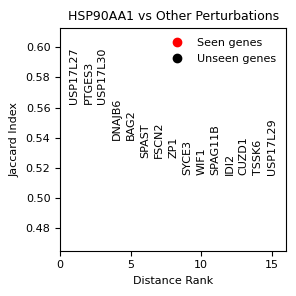

In [ ]:
def trim_cond(cond):
    filtered = '+'.join(p for p in cond.split('+') if p != 'ctrl')
    return filtered if filtered else 'ctrl'

perts_in_train = set([item for cond in split_handler.split_dict['train'] for item in trim_cond(cond).split('+')])

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(3, 3))
n_plot = 15
df_plot = jaccard_df.head(n_plot)

for idx, row in df_plot.iterrows():
    label_color = 'red' if row['perturbation'] in perts_in_train else 'black'
    plt.text(
        row['distance_rank'],
        row['jaccard_index'],
        row['perturbation'],
        fontsize=8,
        color=label_color,
        ha='center',
        va='bottom',
        rotation=90,
    )

plt.xlabel('Distance Rank', fontsize=8)
plt.ylabel('Jaccard Index', fontsize=8)
plt.xlim(df_plot['distance_rank'].min() - 1, df_plot['distance_rank'].max() + 1)
plt.ylim(df_plot['jaccard_index'].min() - 0.05, df_plot['jaccard_index'].max() + 0.05)
plt.title(f'{query} vs Other Perturbations', fontsize=9)

legend_handles = [
    Line2D([0], [0], color='red', lw=0, marker='o', markersize=6, label='Seen genes'),
    Line2D([0], [0], color='black', lw=0, marker='o', markersize=6, label='Unseen genes'),
]
plt.legend(handles=legend_handles, loc='best', frameon=False)

plt.tight_layout()
plt.savefig(f'../data/final_plots/top_{n_plot}_{query}_rank_plot_jaccard.pdf', dpi=300)
plt.show()

<Axes: title={'center': 'HSP90AA1 Perturbation Down'}, xlabel='Combined Score'>

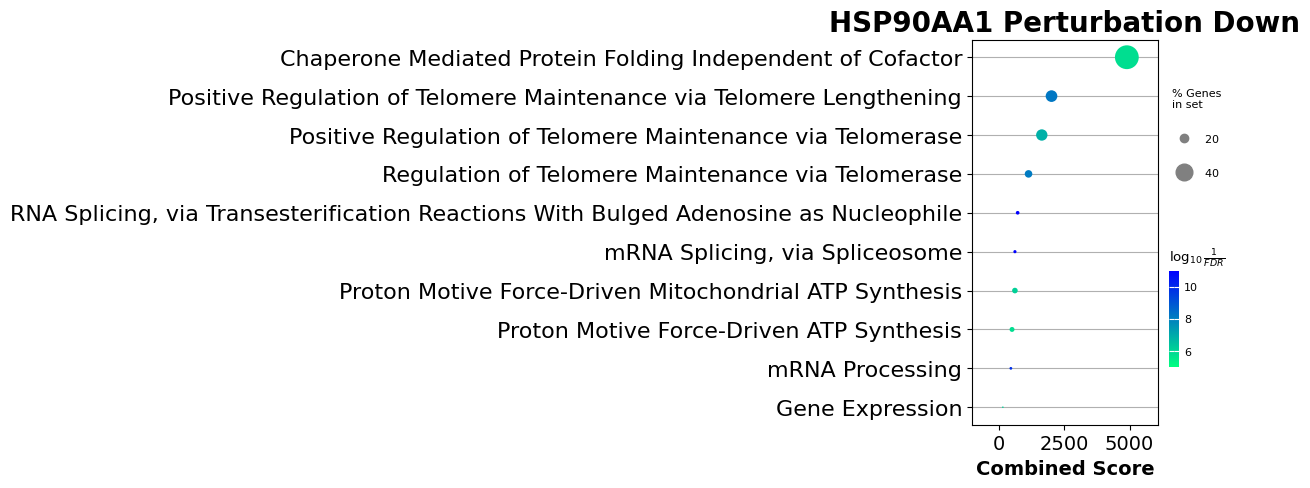

In [ ]:
import gseapy as gp
enr_down = gp.enrich(gene_list=res[query][-100:].to_list(),
                        gene_sets='GO_Biological_Process_2025')
enr_down.res2d['Simplified_Term'] = enr_down.res2d['Term'].apply(lambda x: x.split(' (')[0])
gp.dotplot(enr_down.res2d, figsize=(3,5), y = "Simplified_Term", 
           title=f"{query} Perturbation Down", cmap = plt.cm.winter_r)

In [ ]:
import gseapy as gp
enr_down = gp.enrich(gene_list=res[query][-100:].to_list(),
                        gene_sets='GO_Biological_Process_2025')
enr_down.res2d['Simplified_Term'] = enr_down.res2d['Term'].apply(lambda x: x.split(' (')[0])
gp.dotplot(enr_down.res2d, figsize=(3,5), y = "Simplified_Term",
           title=f"{query} Perturbation Down", cmap = plt.cm.winter_r,
           ofname=f'../data/final_plots/{query}_down_enrich_go.pdf')